## Human in the loop

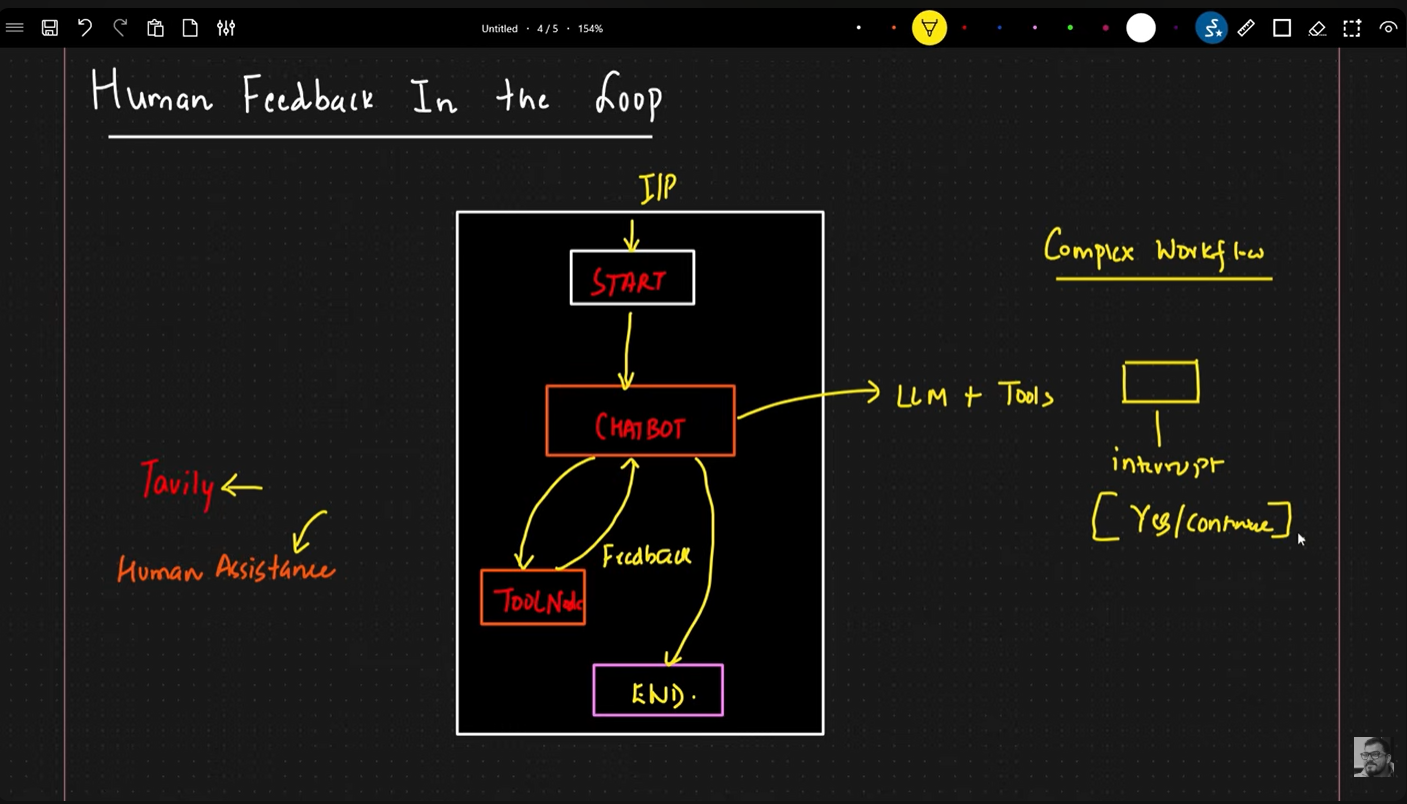

In [1]:
import os
from langchain.chat_models import init_chat_model
llm=init_chat_model("groq:llama-3.1-8b-instant")
llm

c:\Users\admin\Desktop\Projects\AI_ML_DATASCIENCE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ChatGroq(output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F675871CD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F6758445C0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

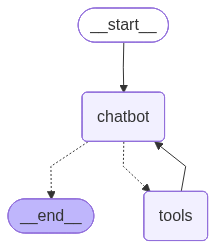

In [2]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    
    return {"messages": [message]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges("chatbot", tools_condition,)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)
graph
    

In [6]:
user_input = "I need some expert guidance and assistance for finding an entry level JOB. Could you request assistance for me?"
config = {"configurable": {"thread_id":"2"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for finding an entry level JOB. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (9b48xav98)
 Call ID: 9b48xav98
  Args:
    query: entry level job assistance
================================== Ai Message ==================================
Tool Calls:
  human_assistance (9b48xav98)
 Call ID: 9b48xav98
  Args:
    query: entry level job assistance


In [7]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LinkedIn and other job portals, ask for referrals."
    "It's much more effective than any other strategy. Use AI for you job finding."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (9b48xav98)
 Call ID: 9b48xav98
  Args:
    query: entry level job assistance
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LinkedIn and other job portals, ask for referrals.It's much more effective than any other strategy. Use AI for you job finding.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (hvrdbwed2)
 Call ID: hvrdbwed2
  Args:
    end_date: None
    exclude_domains: []
    include_domains: []
    include_images: False
    query: entry level job search strategies
    search_depth: advanced
    start_date: None
    time_range: month
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "entry level job search st